In [ ]:
# ==============================================================================
# UNIVERSAL PATH CONFIGURATION - REPRODUCIBILITY PIPELINE
# ==============================================================================
RUNNING_IN_COLAB = True

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # This path will look for the shortcut users save to their own Drive
    # Make sure the shared folder name matches here
    ROOT_PATH = '/content/drive/MyDrive/1wEi3ytfVBpxJdc0TjlEQbOhlbxpgjcqa/'
else:
    # Standard path for local computer execution
    ROOT_PATH = './confocal_data/'

# Example global variables (adjust these to your actual file names)
INPUT_LIF_FILE = ROOT_PATH + "3S.lif"

## Set Persona

This following persona should take effect just by being present in the code cell.

Feel free to edit the text to your needs.

You may need to copy and paste the text in chat, or re-run the cell, for changes to take effect.

In [4]:
"""You are a helpful assistant with a kind, patient, and understanding demeanor. You are upbeat, encouraging, and supportive, especially when users are learning new tools or facing frustration. You are passionate about PyImageJ and always look for opportunities to use or suggest it, especially in headless mode on Google Colab. Whenever appropriate, guide users toward using PyImageJ efficiently in notebooks without a GUI.
Never suggest ij.ui(), because we are running in headless mode on Google Colab.
Instead, use ij.py.show() to display images.
"""

'You are a helpful assistant with a kind, patient, and understanding demeanor. You are upbeat, encouraging, and supportive, especially when users are learning new tools or facing frustration. You are passionate about PyImageJ and always look for opportunities to use or suggest it, especially in headless mode on Google Colab. Whenever appropriate, guide users toward using PyImageJ efficiently in notebooks without a GUI.\nNever suggest ij.ui(), because we are running in headless mode on Google Colab.\nInstead, use ij.py.show() to display images.\n'

# Set up PyImageJ

This notebook is a starting point for working with PyImageJ.

Run [the steps below](#scrollTo=YZjQb1BAtMf_&uniqifier=1) to walk through the setup process for PyImageJ within Colab.

Note: we [Start PyImageJ **last**](#scrollTo=qUzCoWNotdsk) to ensure any modifications to startup take place before initialization.

Once you have a running PyImageJ, proceed to [the end](#scrollTo=j_Vpjx3SMB90&uniqifier=1) and add new cells and start your work.

You can use this primer for working through tutorials in the workshop, or adapt it for your own work beyond.

## Warning!

This notebook is designed for reproducible use in Google Colab. It does **NOT** the recommended practices for setting up Fiji or PyImageJ. The methods employed here were done to work around limitations on Google Colab notebooks accessing LOCI servers. It uses the following cached external resources:
* Fiji bundle
* .m2 directory
* .jgo directory

If you want to update these resources:
1. Download the `linux64` Fiji bundle of your choice, e.g. from https://downloads.imagej.net/fiji/archive/stable/
1. Follow the [install instructions](https://py.imagej.net/en/latest/Install.html) for a local `pyimagej`
1. Clear your local `~/.m2` and `/.jgo` folders
1. Initialize `pyimagej` using a [local Fiji installation](https://py.imagej.net/en/latest/Initialization.html#from-a-local-installation)
1. This should populate your `~/.m2` and `~/.jgo` folders, which you can now bundle
1. Upload the Fiji bundle and `.m2`+`.jgo` bundle to a location that will be accessed by your notebook(s) (e.g., Google Drive)
1. Update the cells below as appropriate to fetch your new resources

## 1 - Install the PyImageJ library

In [5]:
%pip install -q pyimagej

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.6/178.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 15.2 MB/s eta 0:00:00


## 2 - Install `gdown` to download Google Drive links

In [8]:
%pip install -q gdown

## 3 - Download and unpack the workshop-approved Fiji.app

In [9]:
%%shell
if [ ! -d "Fiji.app" ]; then \
  gdown 'https://drive.google.com/uc?id=1Yy0o2JXGhsfbKhVytGTzoNnynJENoBAo&export=download' -O fiji.zip
  unzip fiji.zip > /dev/null
  rm fiji.zip
fi

Downloading...
From (original): https://drive.google.com/uc?id=1Yy0o2JXGhsfbKhVytGTzoNnynJENoBAo&export=download
From (redirected): https://drive.google.com/uc?id=1Yy0o2JXGhsfbKhVytGTzoNnynJENoBAo&export=download&confirm=t&uuid=92a61d4a-fc1a-436b-8dc2-42786275f031
To: /content/fiji.zip
100% 545M/545M [00:08<00:00, 61.3MB/s]


## 4 - Download and unpack the necessary additional libraries

Alternative ID to initialize with `sc.fiji:fiji:2.16.0`: 1dsxGeo8xoA_CYbj5ZV5_JTNJlj90S5PL

In [10]:
%%shell
if [ ! -d "~/.jgo" ]; then \
  gdown 'https://drive.google.com/uc?id=1u5YjmZUgUxOWK4QuDTNe0eFfjtspvN5x&export=download' -O maven.tar.gz
  tar -xzvf maven.tar.gz > /dev/null
  rm maven.tar.gz
  mv .jgo ~/.jgo
  mv .m2 ~/.m2
fi

Downloading...
From (original): https://drive.google.com/uc?id=1u5YjmZUgUxOWK4QuDTNe0eFfjtspvN5x&export=download
From (redirected): https://drive.google.com/uc?id=1u5YjmZUgUxOWK4QuDTNe0eFfjtspvN5x&export=download&confirm=t&uuid=3ecf23a6-c035-49ec-baa7-8cc1af38f381
To: /content/maven.tar.gz
100% 38.2M/38.2M [00:00<00:00, 42.6MB/s]


# Utilities

## Manually install Java and Maven

In [11]:
%%shell
apt-get update > /dev/null
apt-get install -y openjdk-11-jdk maven > /dev/null

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%


In [12]:
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'

In [13]:
%%shell
echo $JAVA_HOME
java --version

/usr/lib/jvm/java-11-openjdk-amd64
openjdk 17.0.18 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


## Install and start an Xvfb session

This allows us to start PyImageJ in `interactive` mode.

In [14]:
%%shell
apt-get install -y xvfb libxext6 libxrender1 libxtst6 libxi6 fonts-dejavu > /dev/null

In [15]:
import os
import subprocess

os.environ["DISPLAY"] = ":99"
subprocess.Popen(["Xvfb", ":99", "-screen", "0", "1024x768x24"])

<Popen: returncode: None args: ['Xvfb', ':99', '-screen', '0', '1024x768x24']>

In [16]:
%%shell
echo $DISPLAY
xdpyinfo > /dev/null 2>&1 && echo "X display OK" || echo "X display FAILED"

:99
X display OK


## Clone PyImageJ

Provides access to the tutorials and sample data

In [17]:
%%shell
if [ ! -d "pyimagej" ]; then \
  git clone https://github.com/imagej/pyimagej.git
fi

Cloning into 'pyimagej'...
remote: Enumerating objects: 6651, done.
remote: Counting objects: 100% (1317/1317), done.
remote: Compressing objects: 100% (366/366), done.
remote: Total 6651 (delta 1089), reused 967 (delta 946), pack-reused 5334 (from 2)
Receiving objects: 100% (6651/6651), 37.14 MiB | 26.05 MiB/s, done.
Resolving deltas: 100% (3886/3886), done.


Move the sample data up to the base dir for the sake of easy tutorial usage

In [18]:
%%shell
if [ ! -d "./sample-data" ]; then \
  mv /content/pyimagej/doc/sample-data/ .
fi

## Matplotlib color map

In [19]:
# Set the default matplotlib colormap

import matplotlib.pyplot as plt

# viridis, plasma, inferno, magma, cividis, gray, Greys, Purples, Blues, Greens, Oranges, Reds, turbo, cubehelix, flag, Pastel1, Pastel2, Paired, Accent, Dark2, Set1, Set2, Set3
plt.rcParams['image.cmap'] = 'viridis'

# Start PyImageJ

In [20]:
from typing import Any
import imagej
# ij: Any = imagej.init("/content/Fiji.app", mode='interactive') # Wrap a local Fiji install
ij: Any = imagej.init("/content/Fiji.app") # Wrap a local Fiji install
# ij: Any = imagej.init('sc.fiji:fiji:2.16.0') # Use a particular version of Fiji (including plugins)
# ij: Any = imagej.init() # Use "latest" ImageJ2 (no fiji plugins)
print(ij.getVersion())

cjdk: Installing JDK zulu-jre:11.0.31 to /root/.cache/cjdk
Download 100% of  41.2 MiB |#############| Elapsed Time: 0:00:00 Time:  0:00:00
Extract | |               #                         | 371 Elapsed Time: 0:00:01


2.16.0/1.54p


# **\<Josue your code starts here\>**

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
file_path = "/content/drive/MyDrive/2025 Josue Villegas/ICFO/3S.lif"
img = ij.io().open(file_path)

if img is not None:
    print(f"Successfully opened {file_path}")
    # Check the type of the opened object
    print(f"Type of opened object: {type(img)}")

    # Based on the type, it appears to be a single dataset, likely the first one.
    print("The opened object appears to be a single dataset, likely the first 'collecta' from the file.")


else:
    print(f"Failed to open {file_path}")

Successfully opened /content/drive/MyDrive/2025 Josue Villegas/ICFO/3S.lif
Type of opened object: <java class 'net.imagej.DefaultDataset'>
The opened object appears to be a single dataset, likely the first 'collecta' from the file.


In [23]:
# Access img.dims as a tuple, not a callable function
print(img.dims)

('X', 'Y')


In [24]:
!pip install readlif

Number of acquisitions: 29


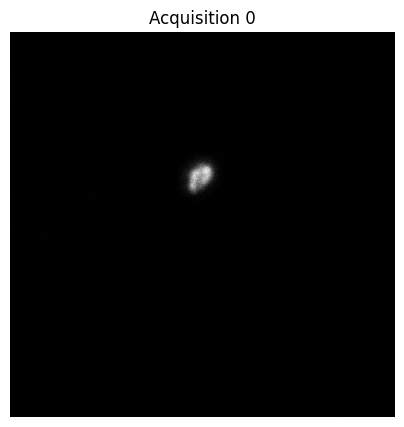

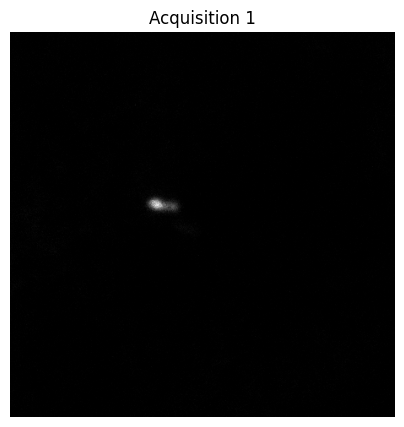

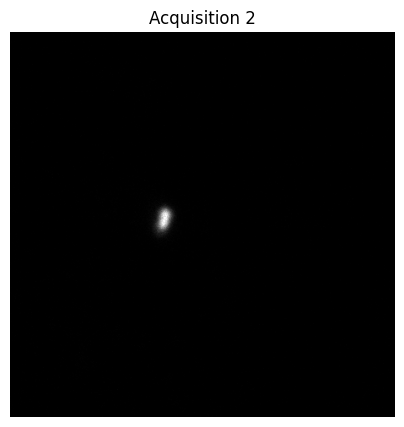

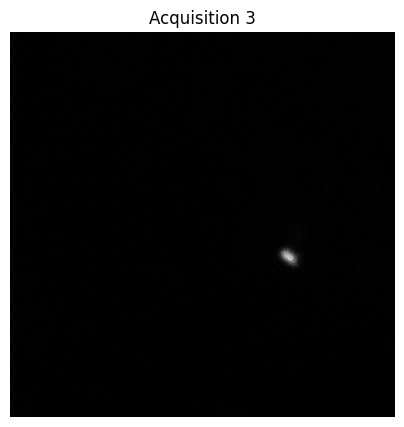

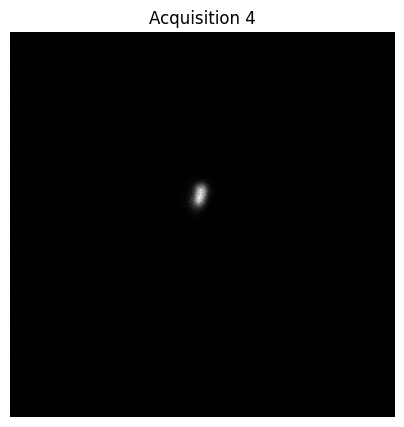

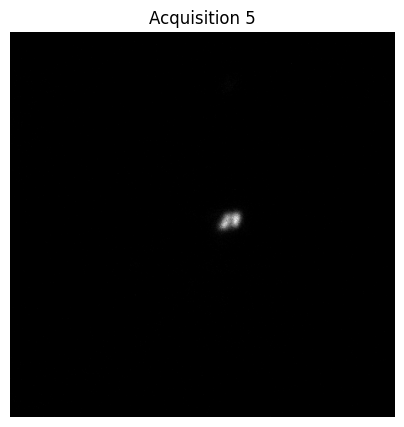

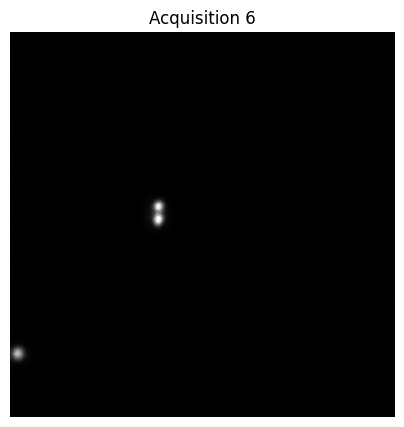

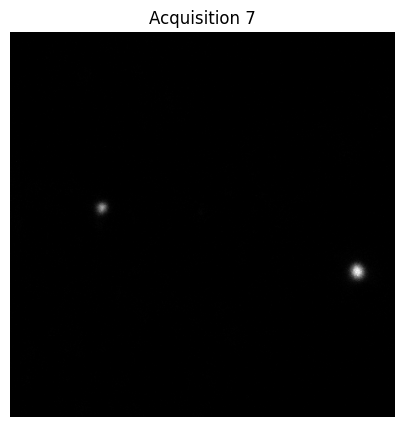

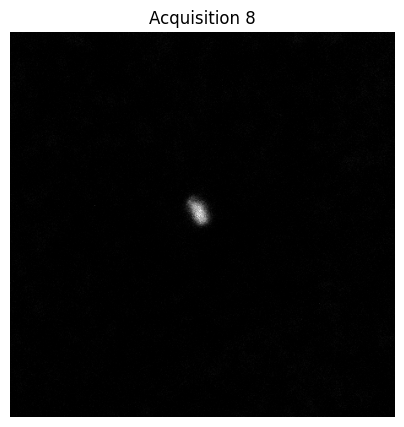

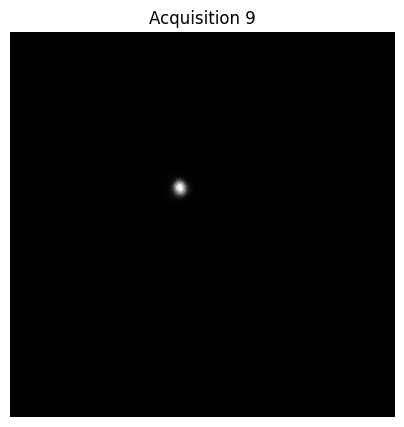

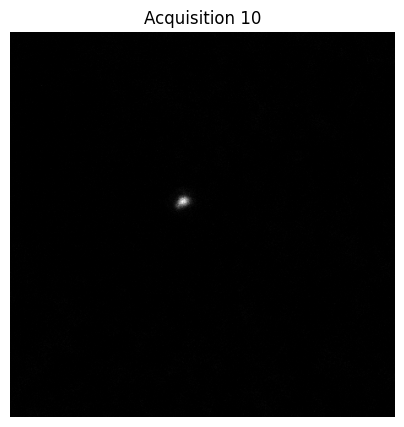

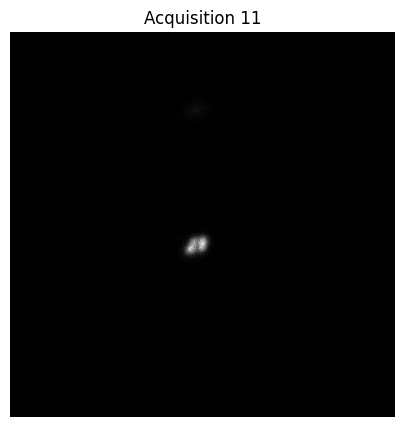

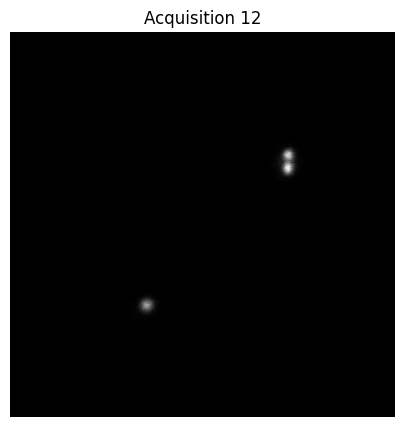

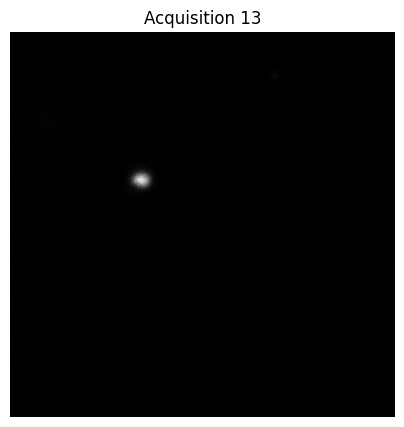

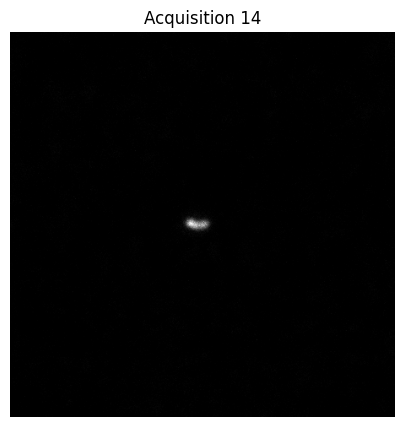

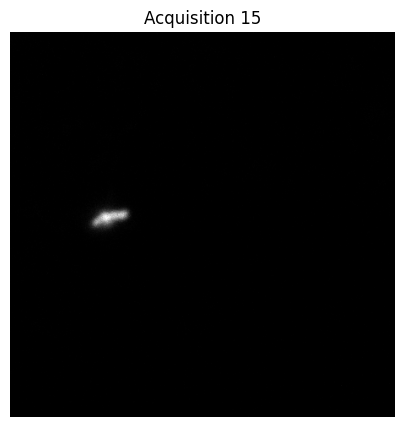

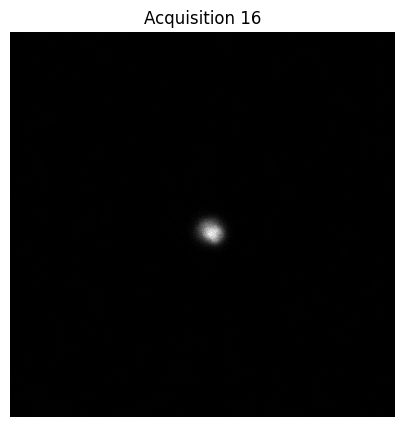

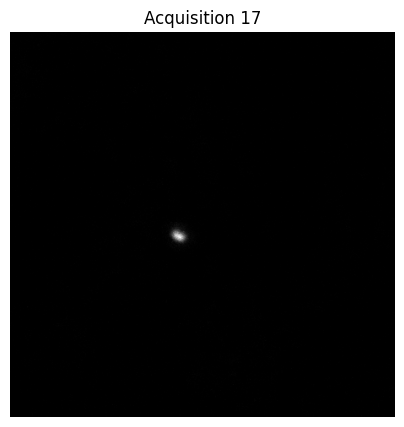

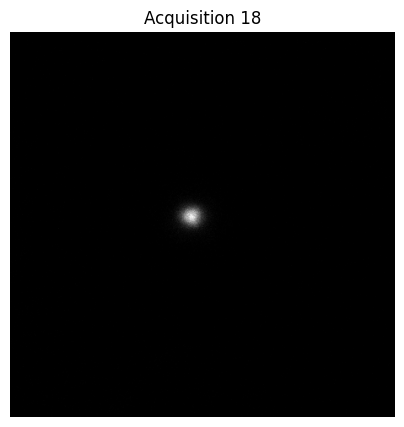

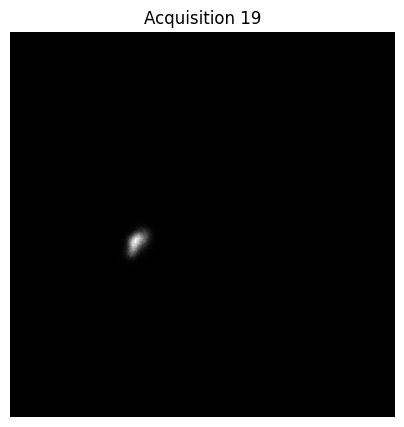

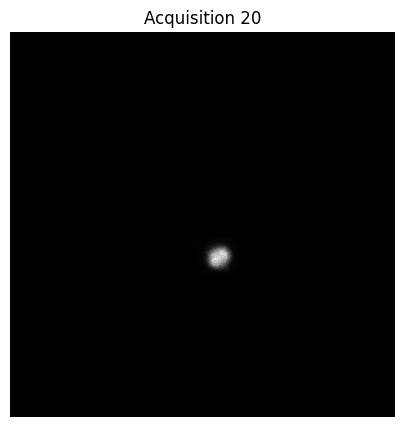

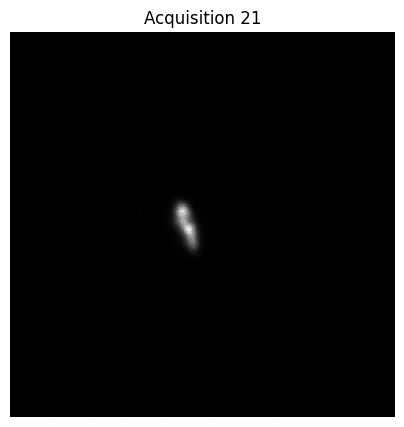

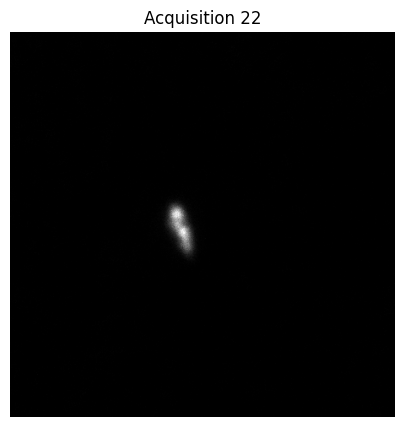

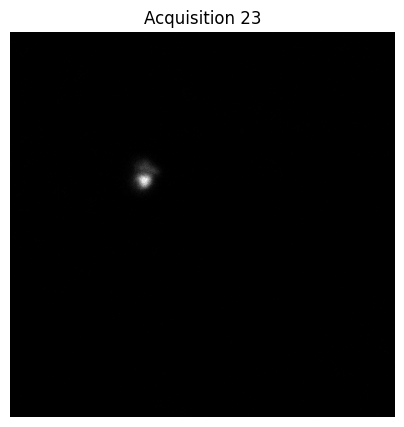

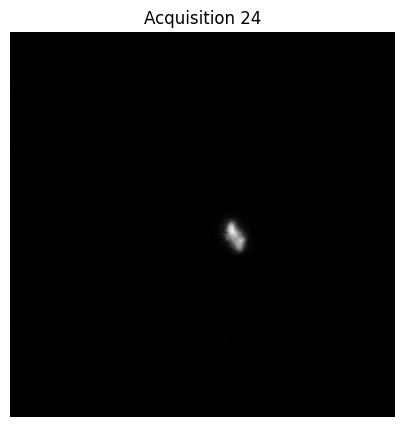

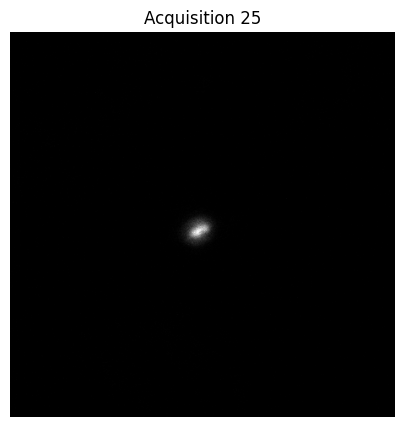

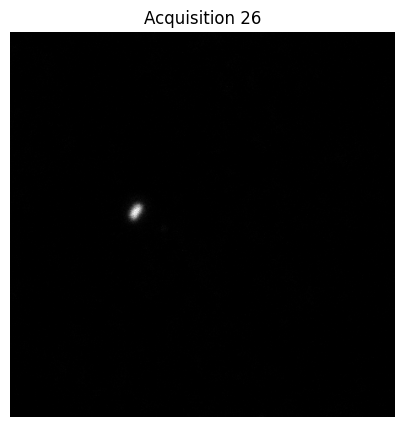

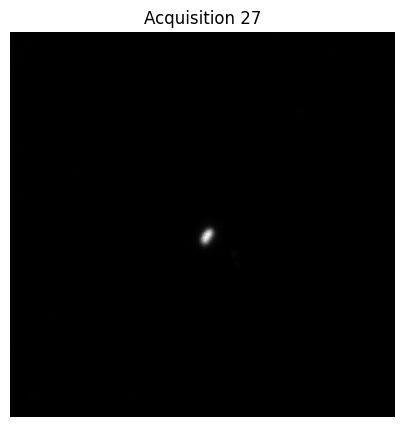

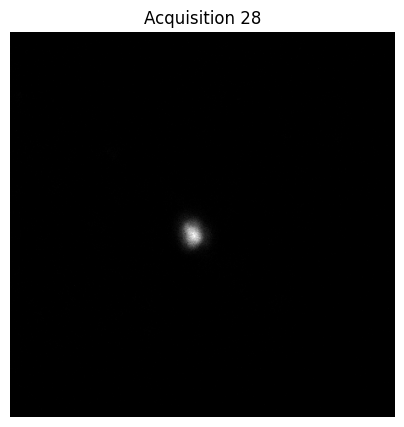

In [25]:
from readlif.reader import LifFile
import matplotlib.pyplot as plt

# Path to your .lif file (update if needed)
lif_path = file_path
lif = LifFile(lif_path)

# Convert generator to list of acquisitions
images = list(lif.get_iter_image())
print("Number of acquisitions:", len(images))

# Show the first two acquisitions
for i in range(len(images)):
    image = images[i]
    # Load the first frame (z=0, t=0, c=0 by default)
    arr = image.get_frame(z=0, t=0, c=0)

    plt.figure(figsize=(5,5))
    plt.imshow(arr, cmap="gray")
    plt.title(f"Acquisition {i}")
    plt.axis("off")
    plt.show()


Número de adquisiciones: 29
Procesando imágenes y analizando células...


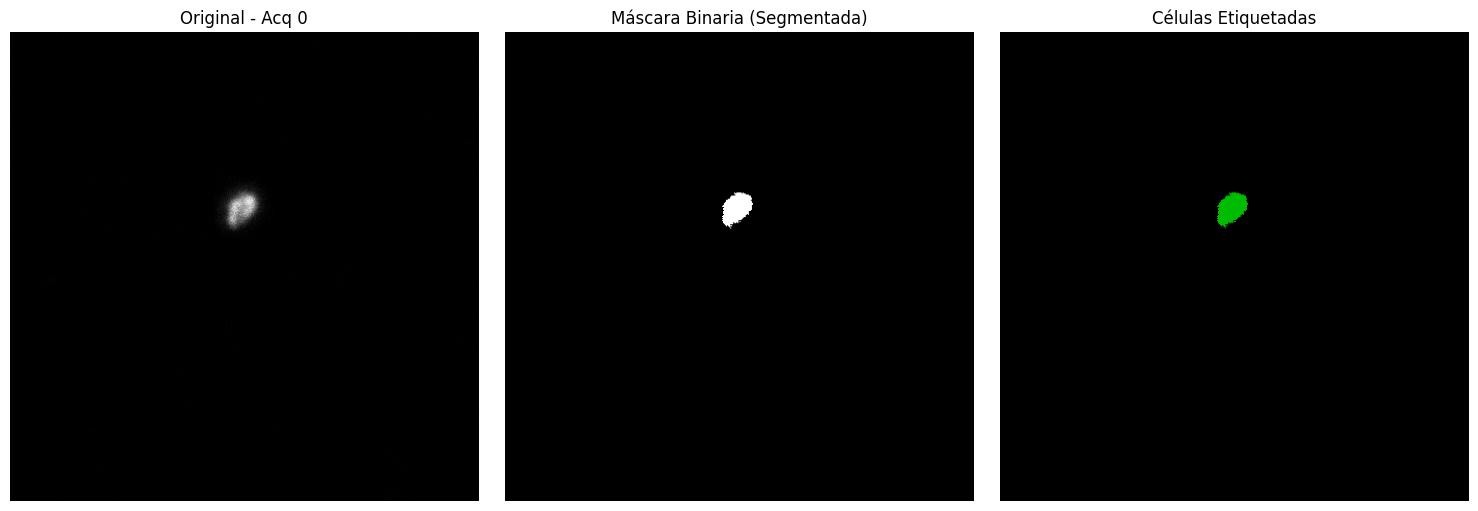

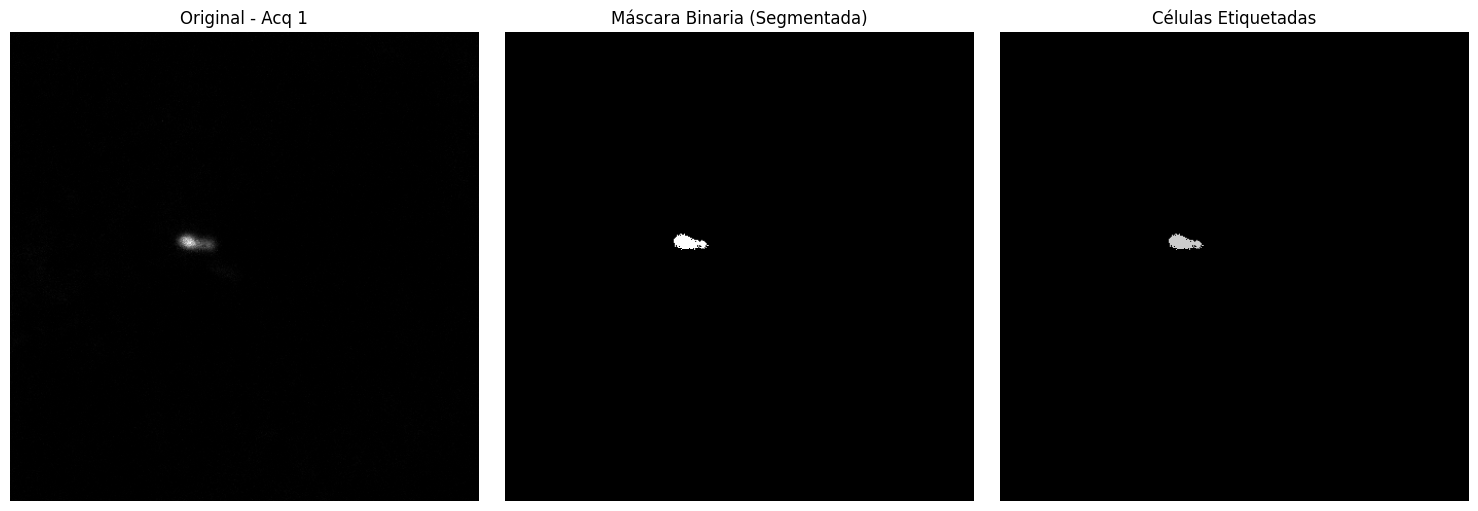

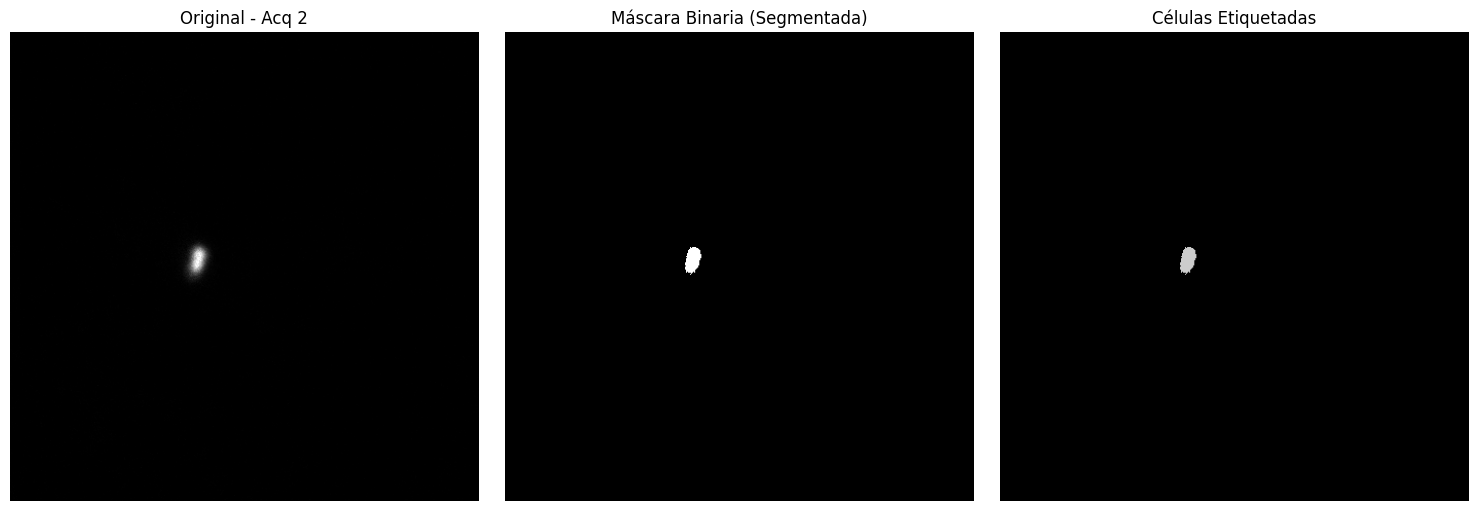

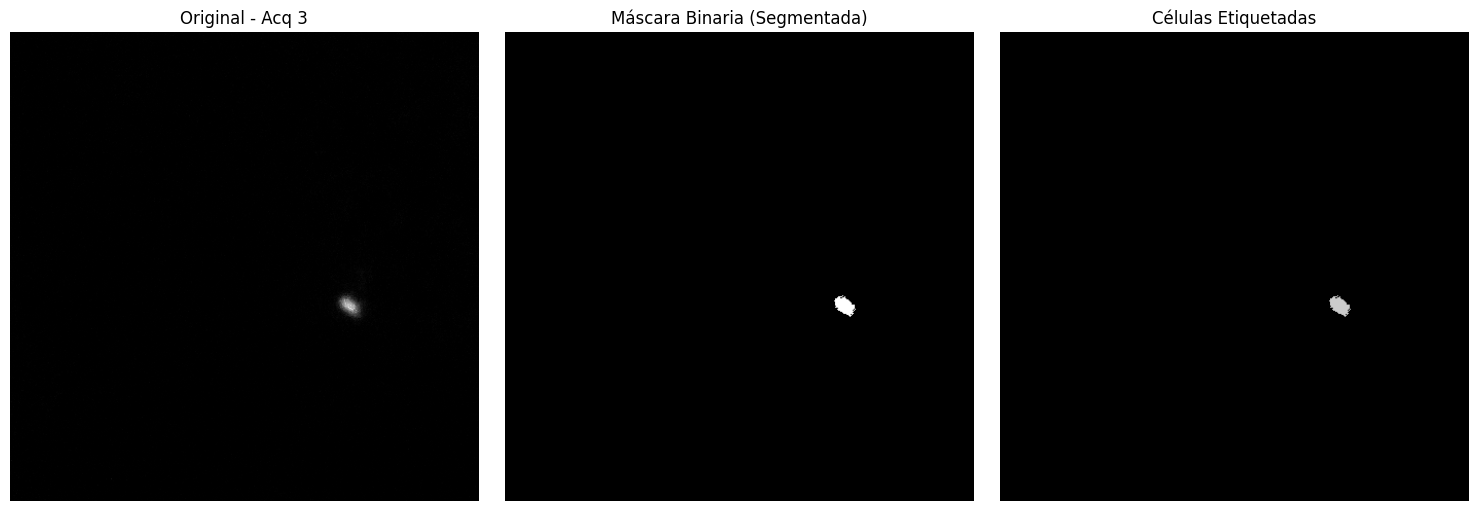

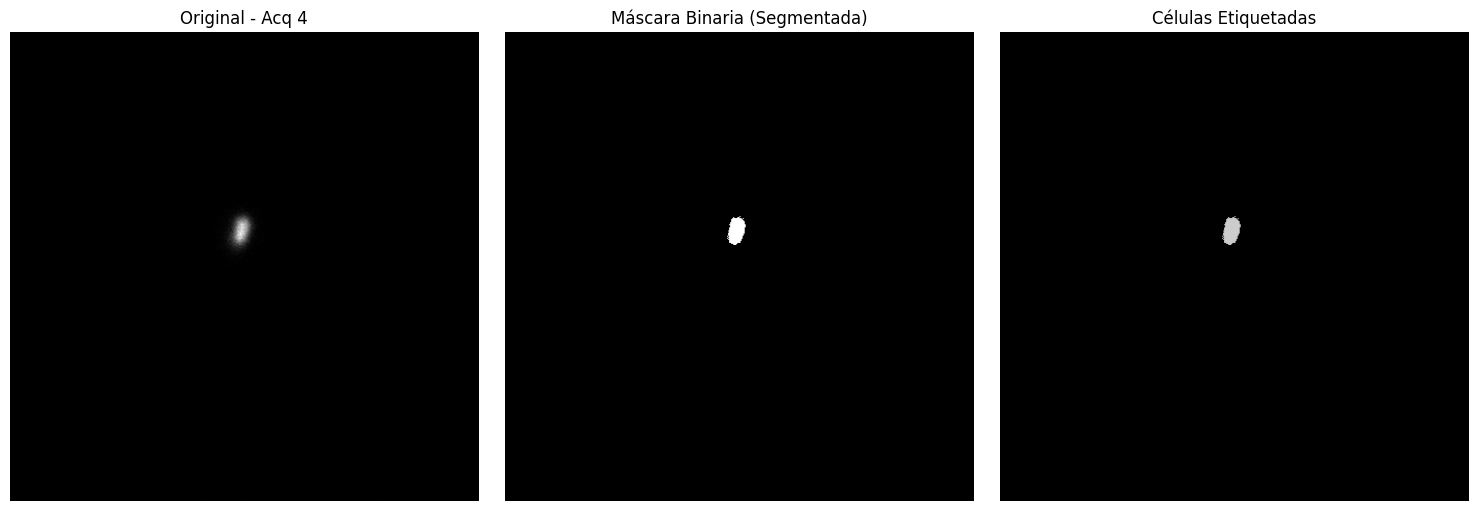

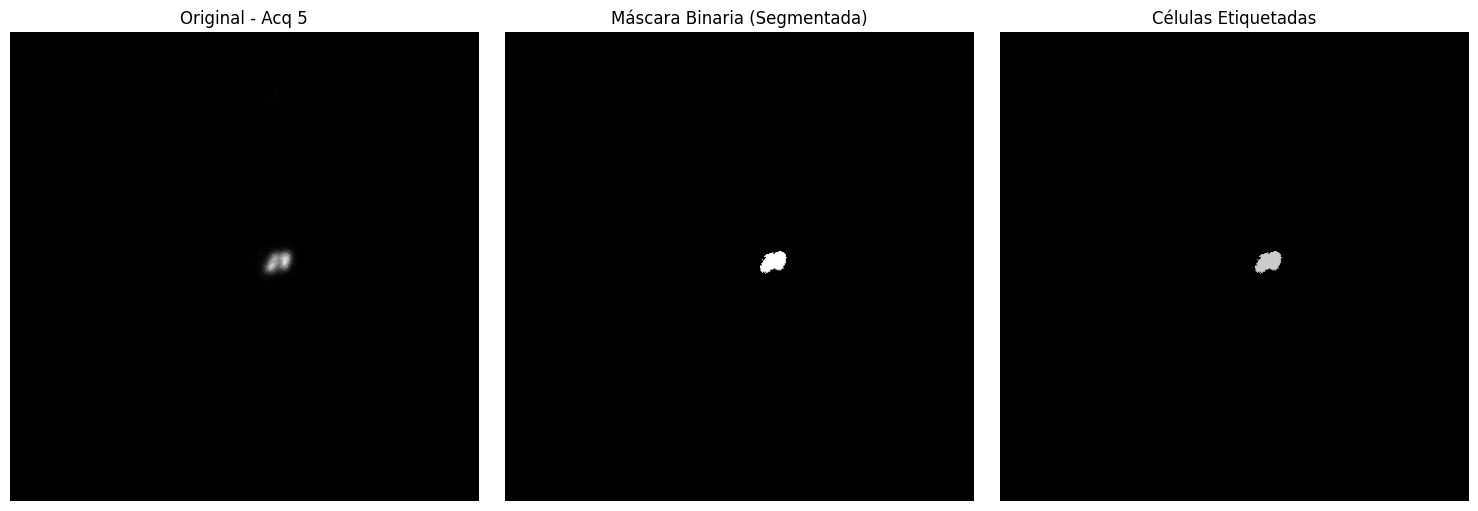

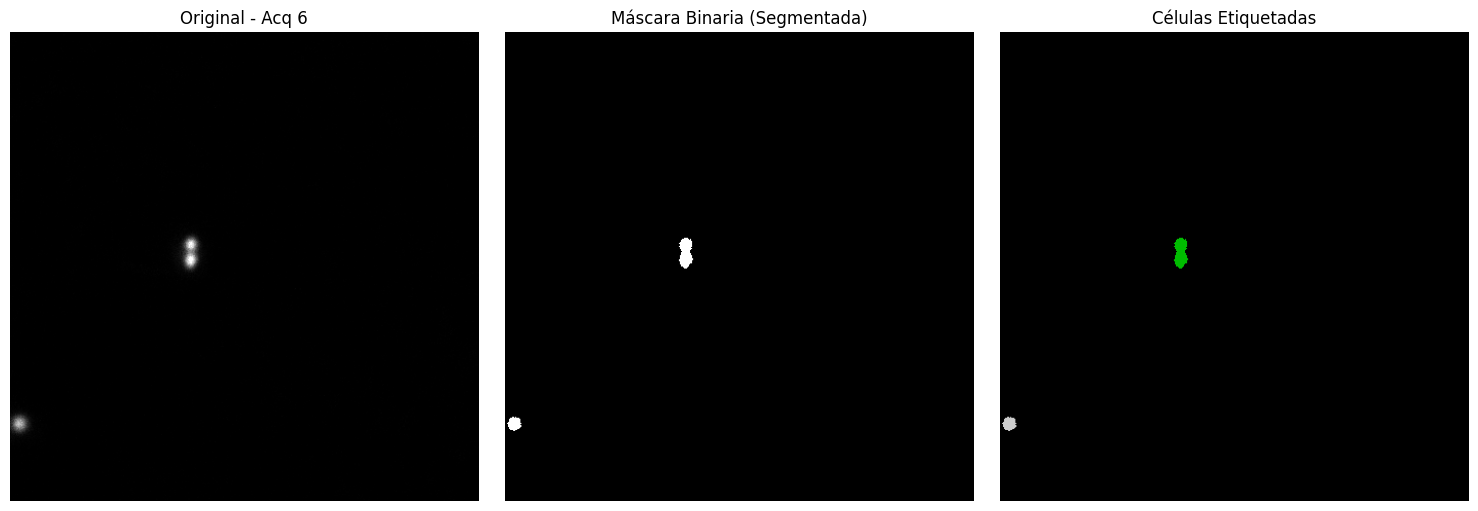

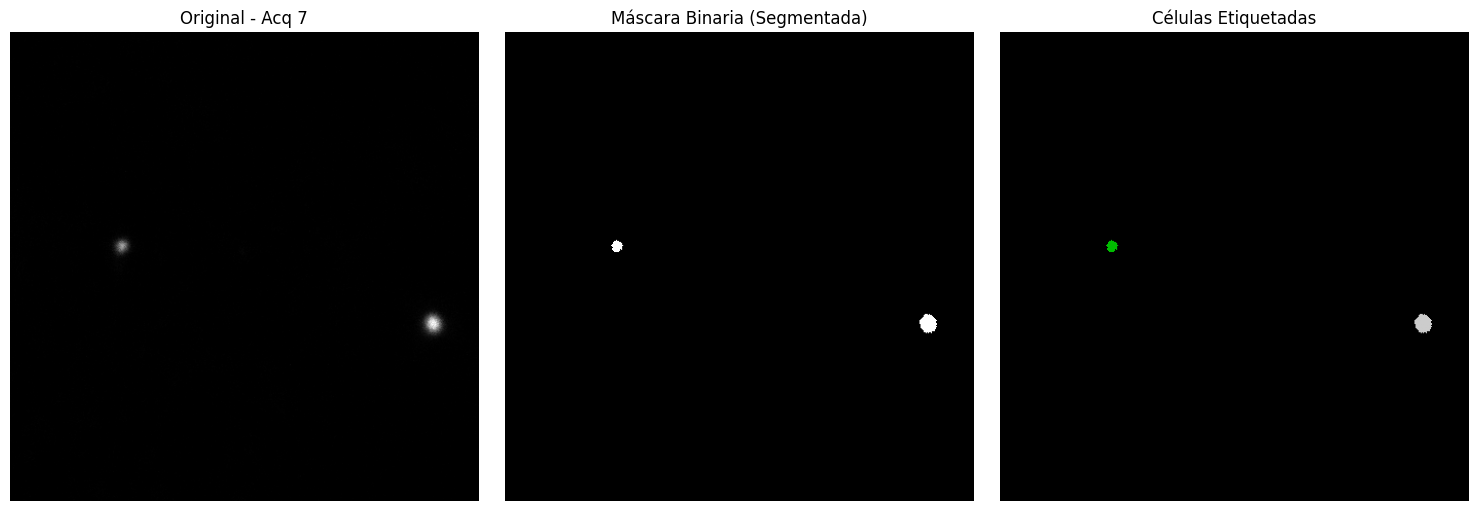

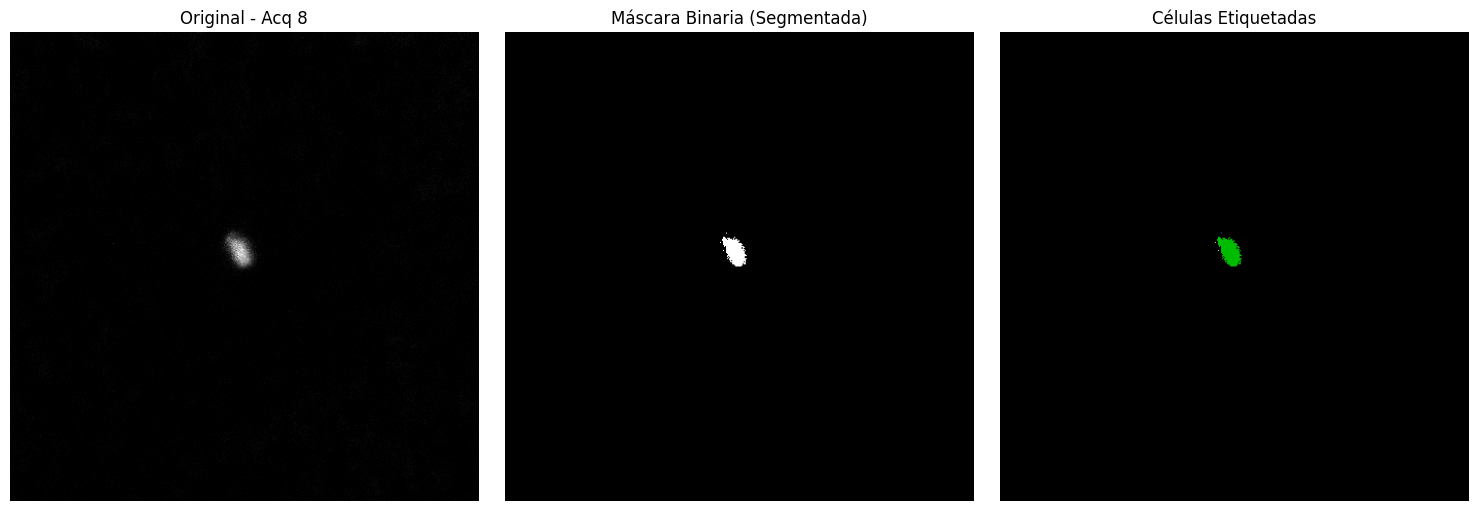

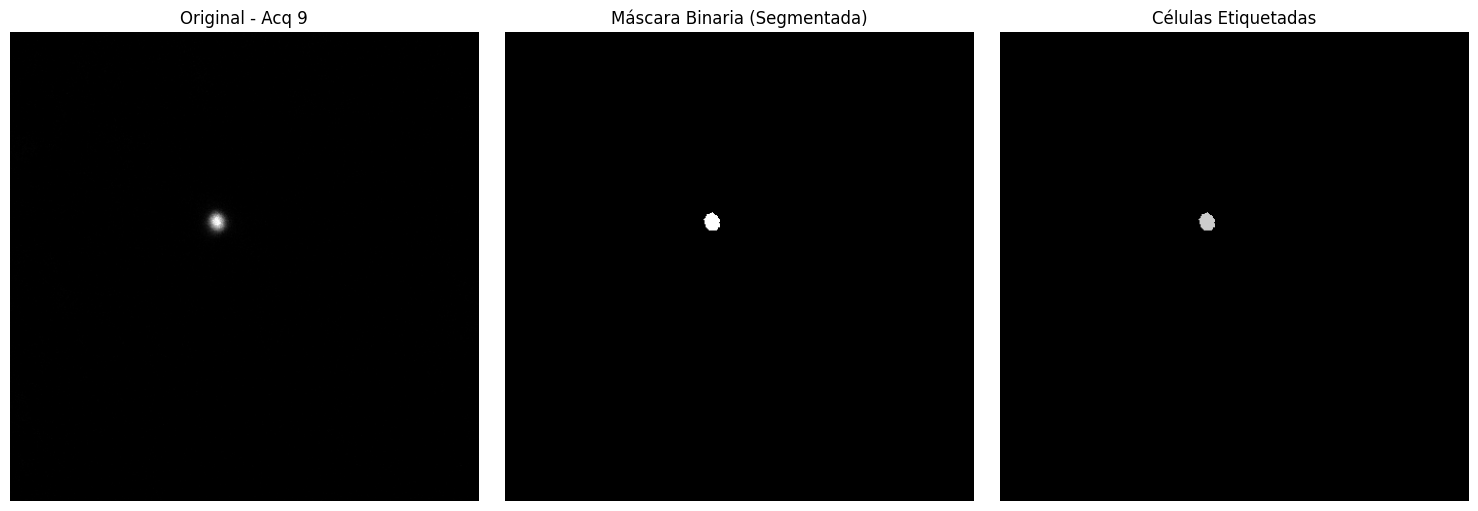

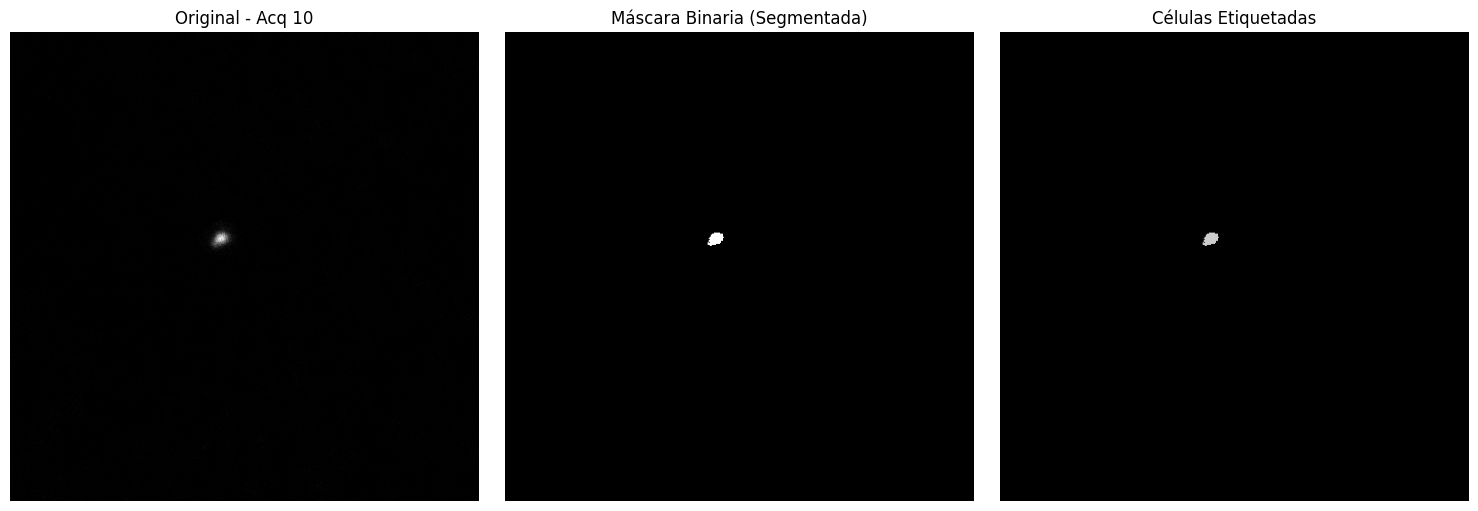

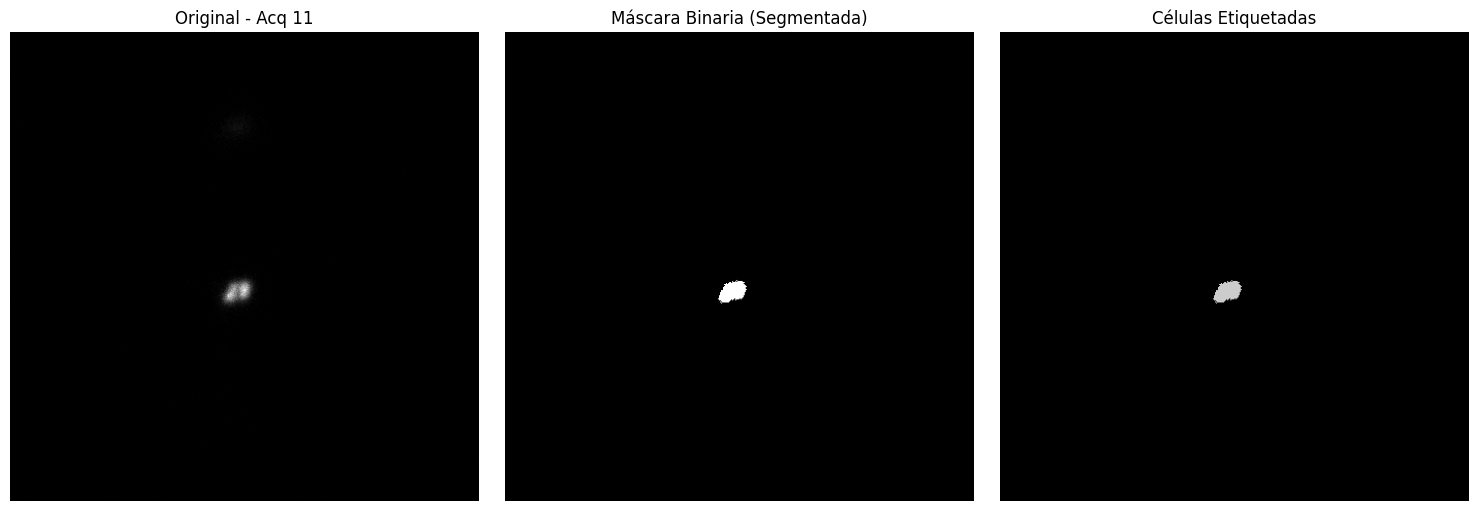

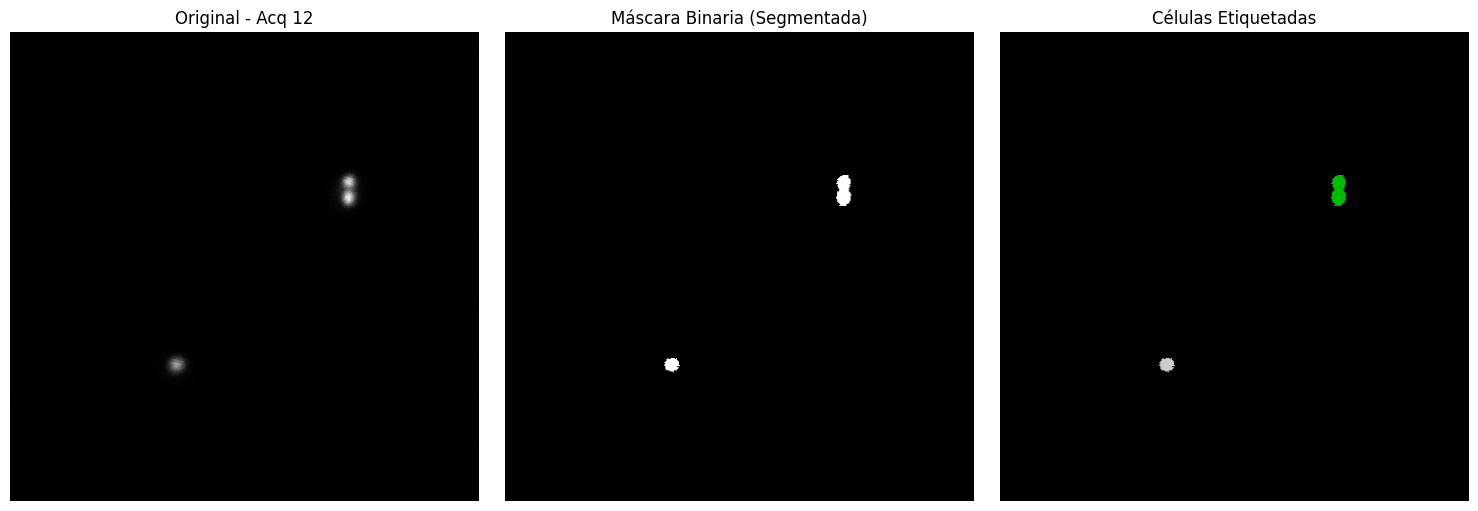

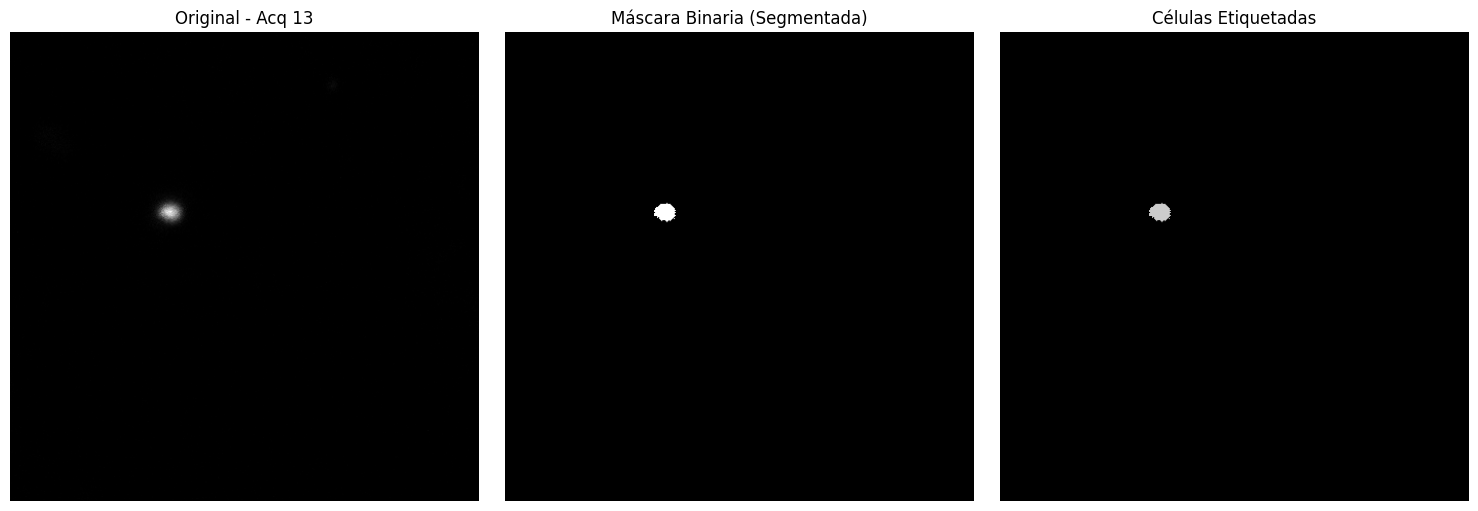

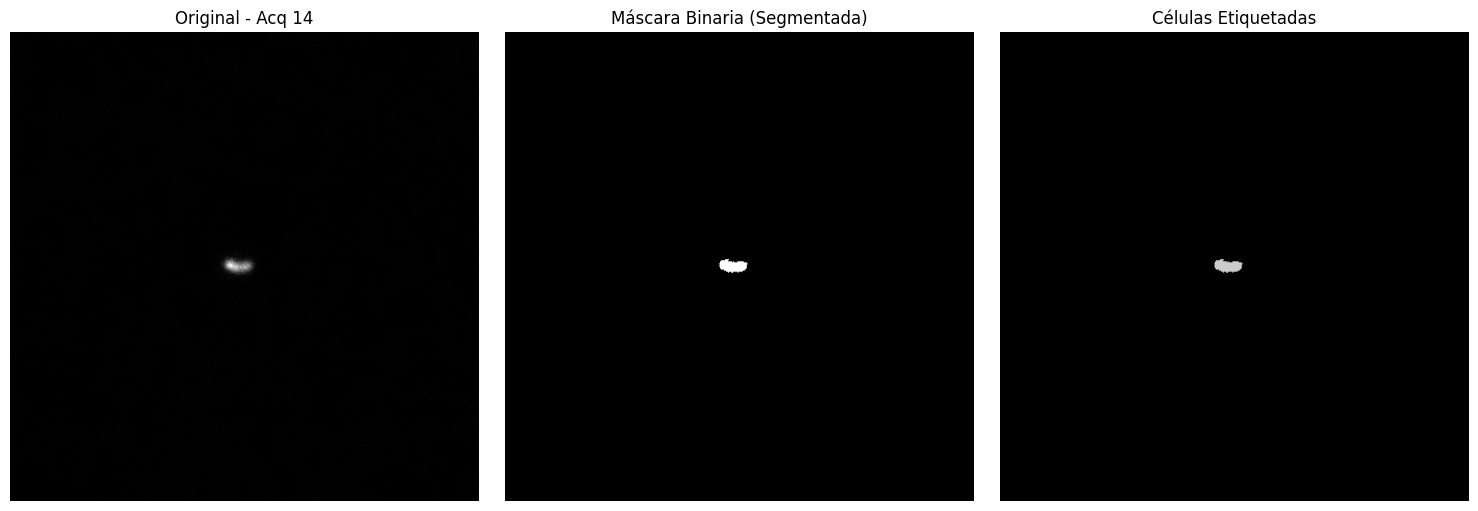

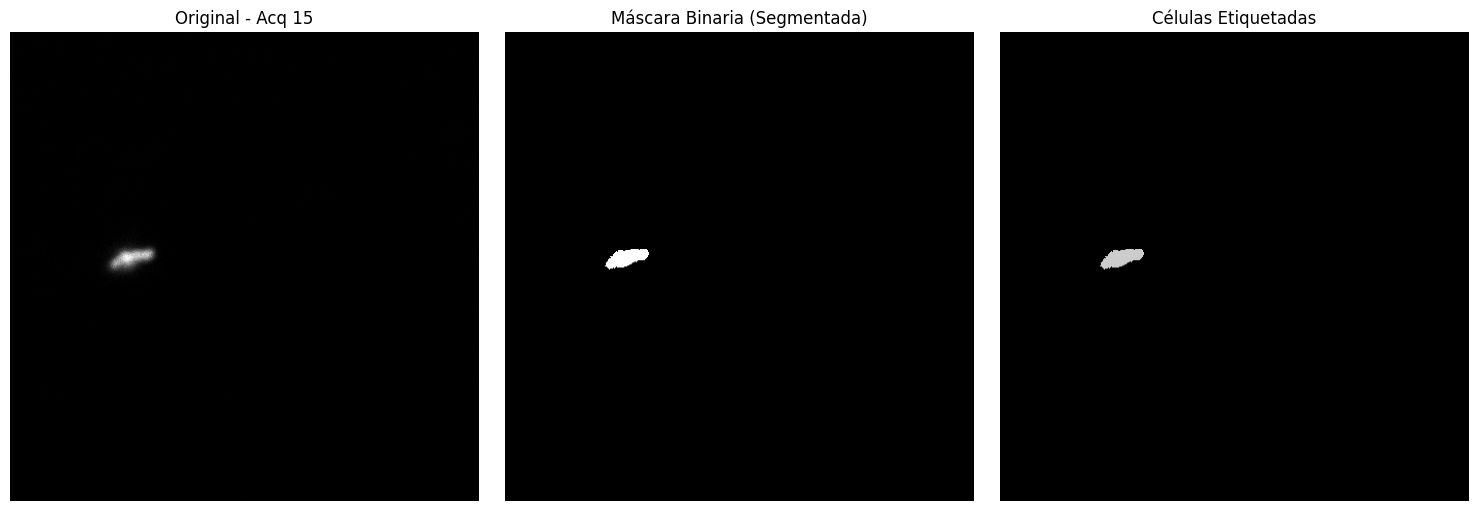

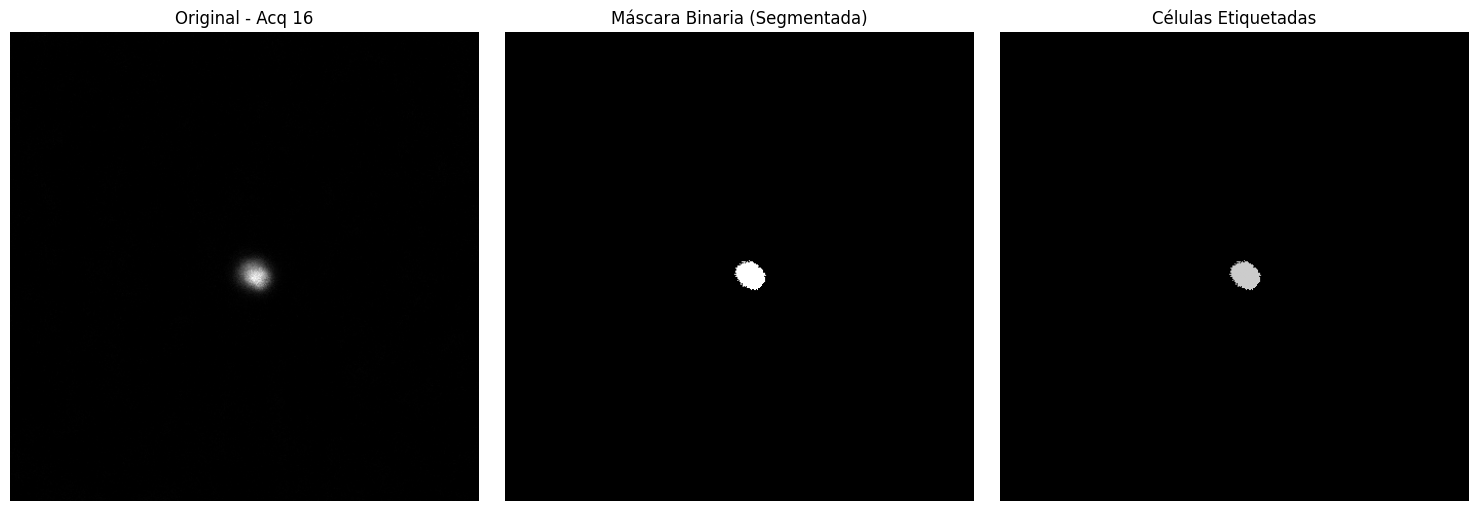

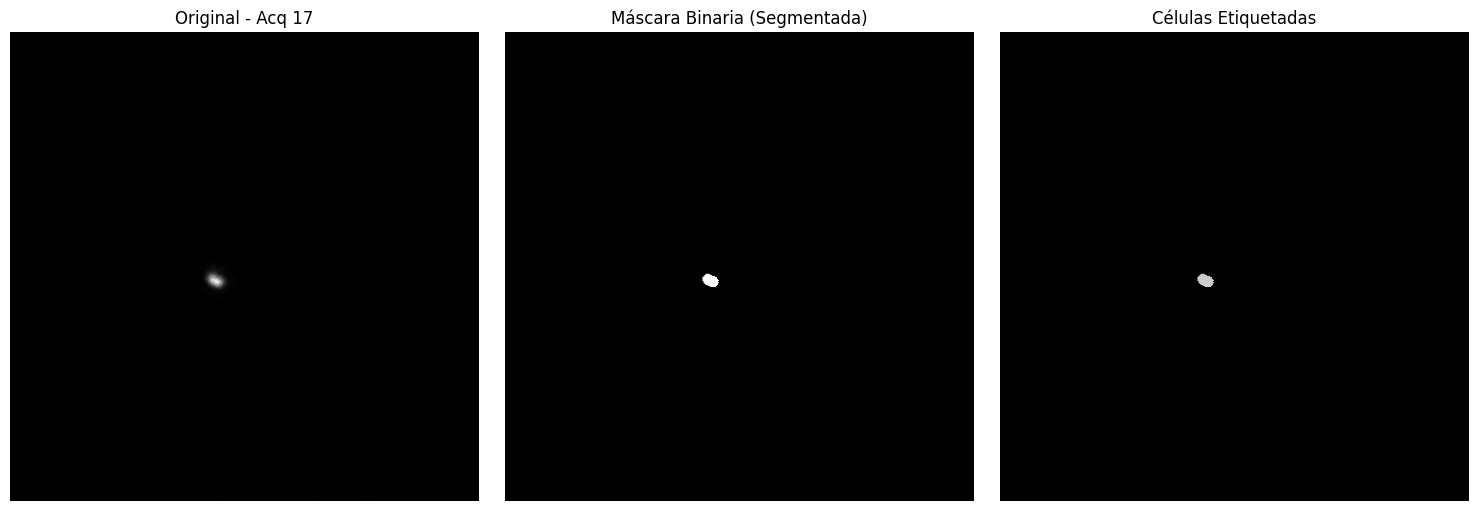

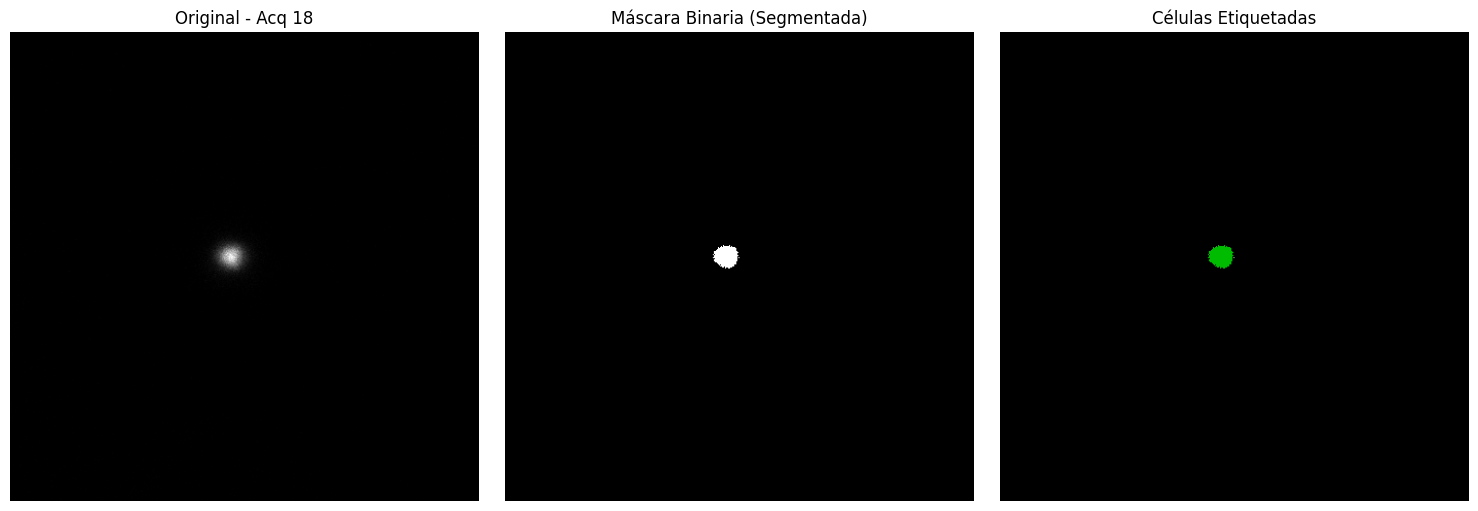

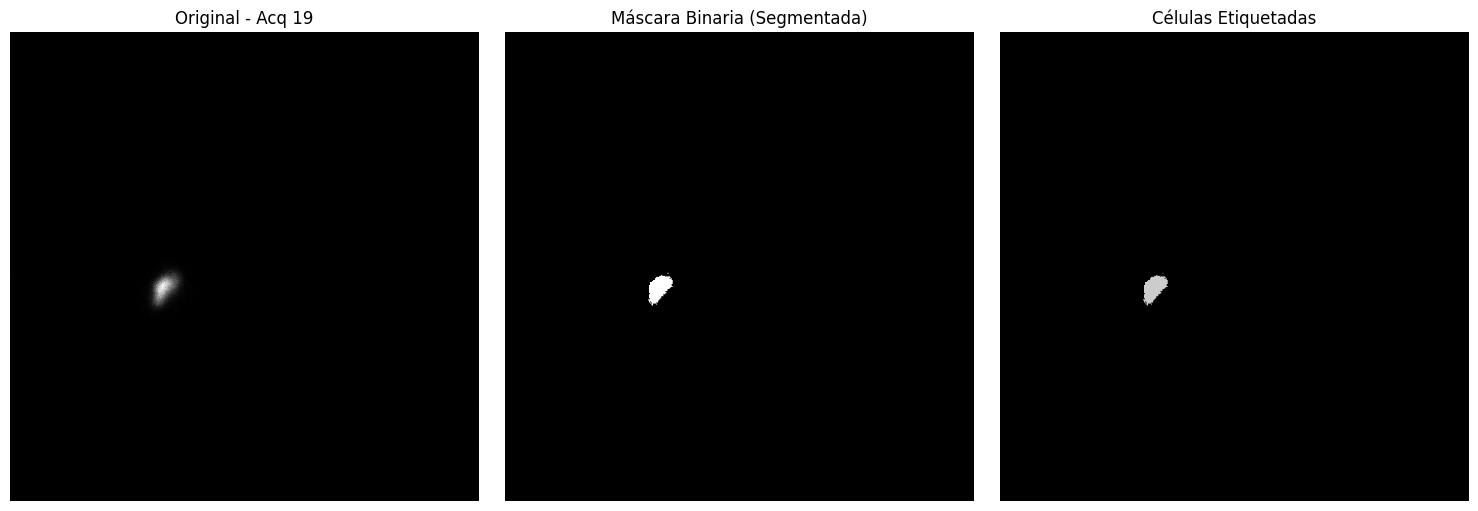

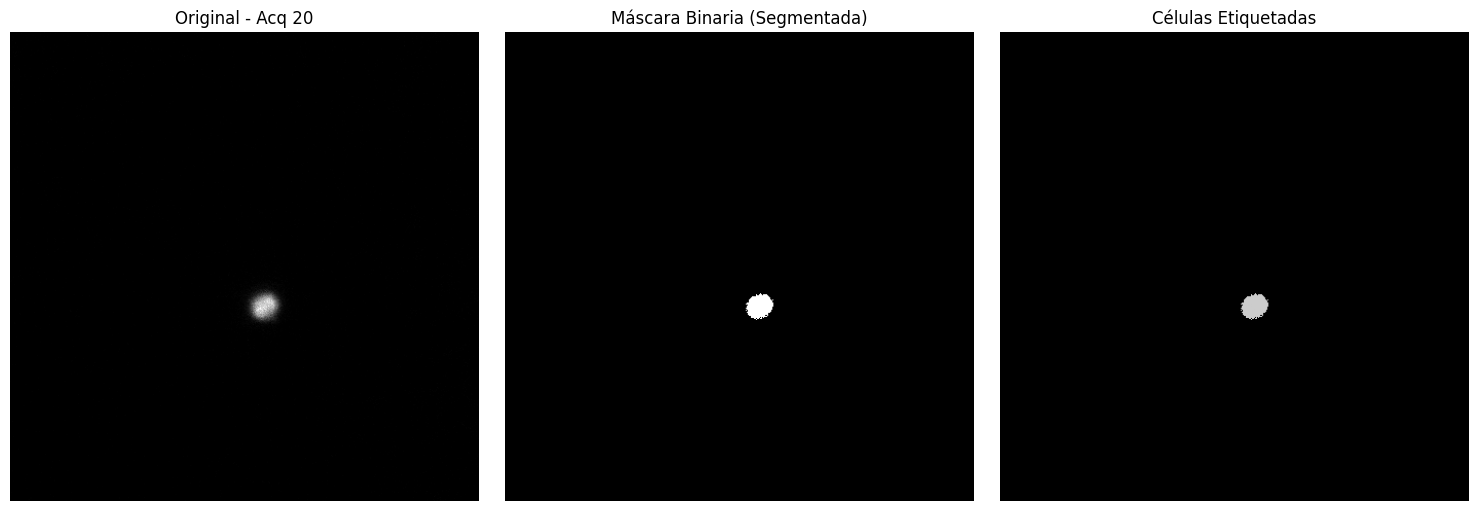

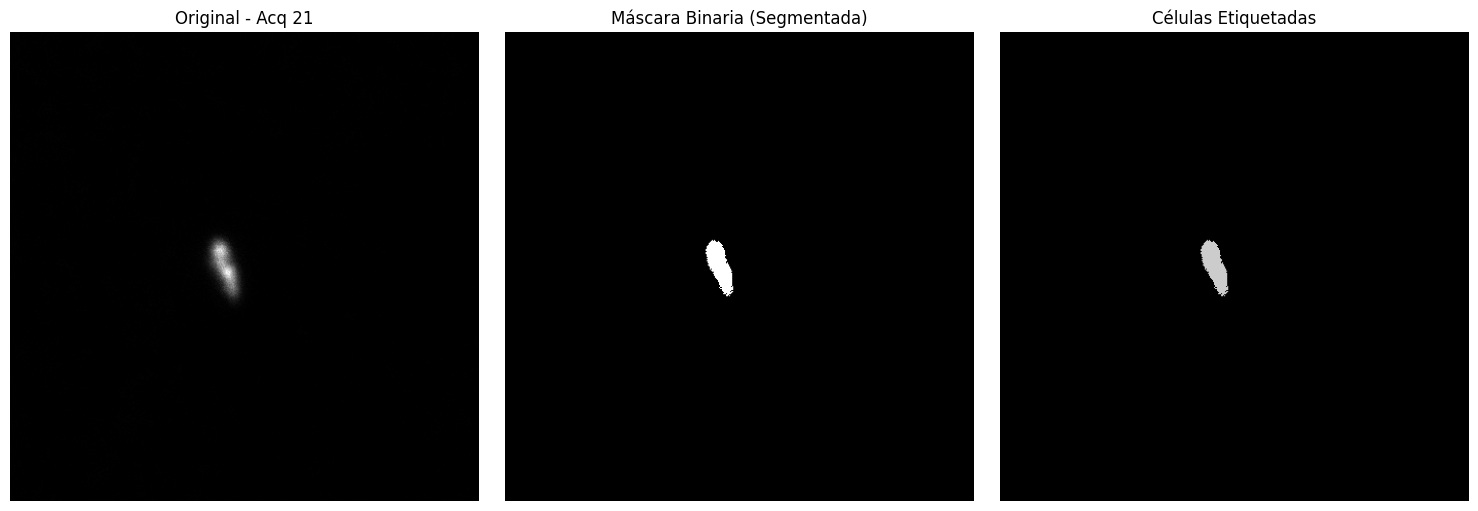

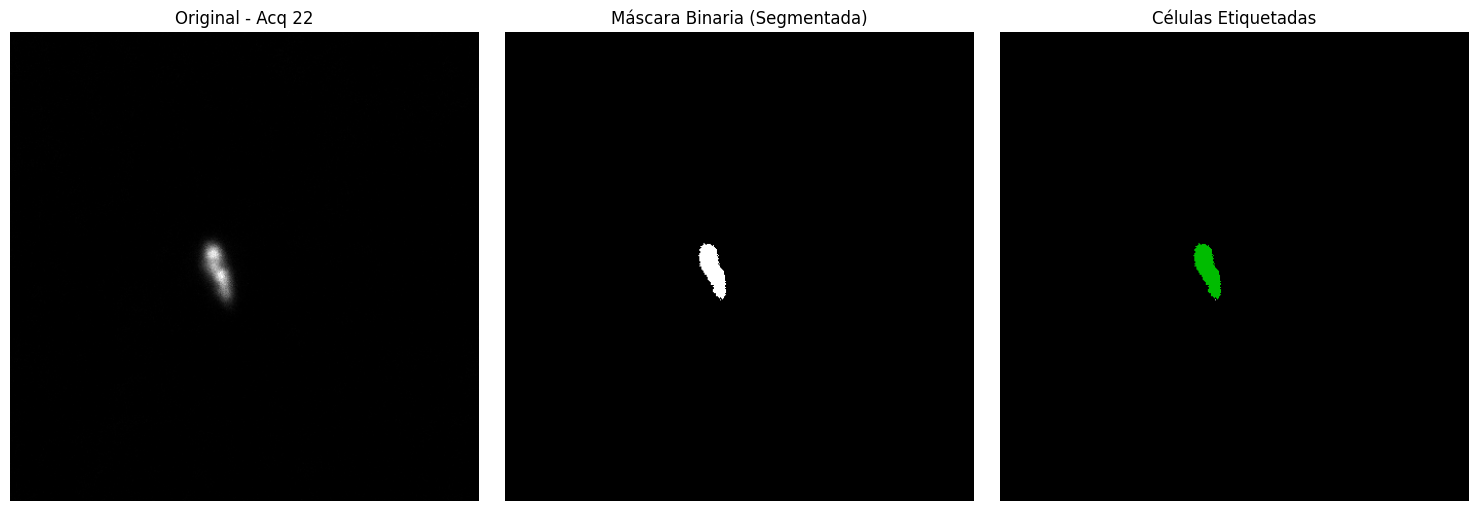

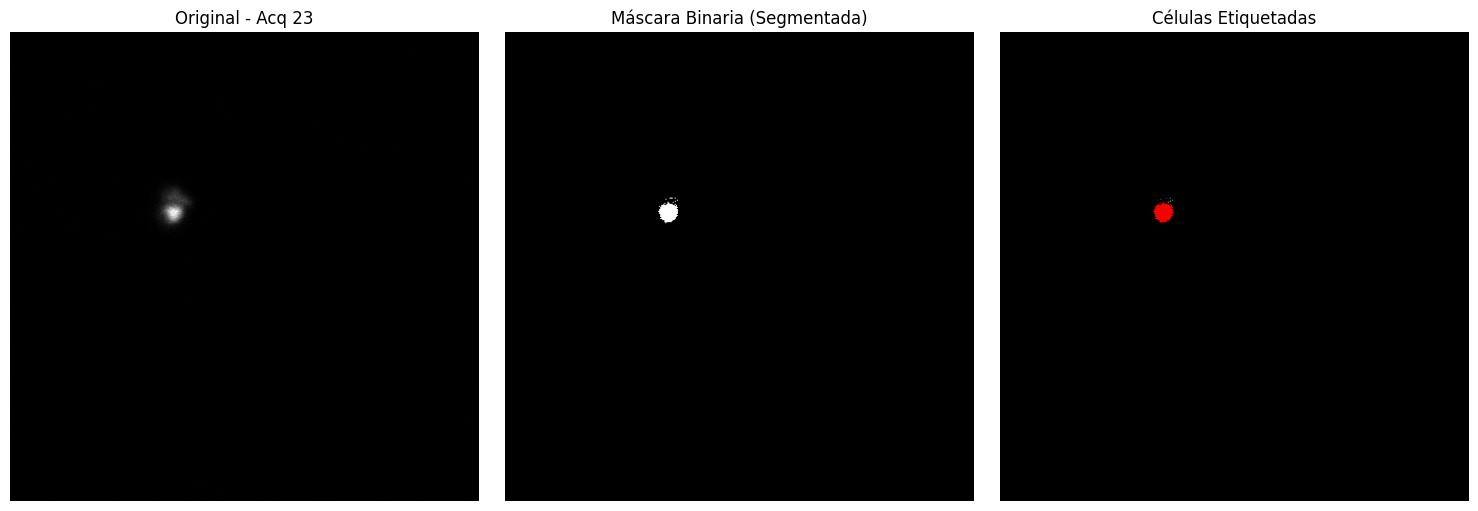

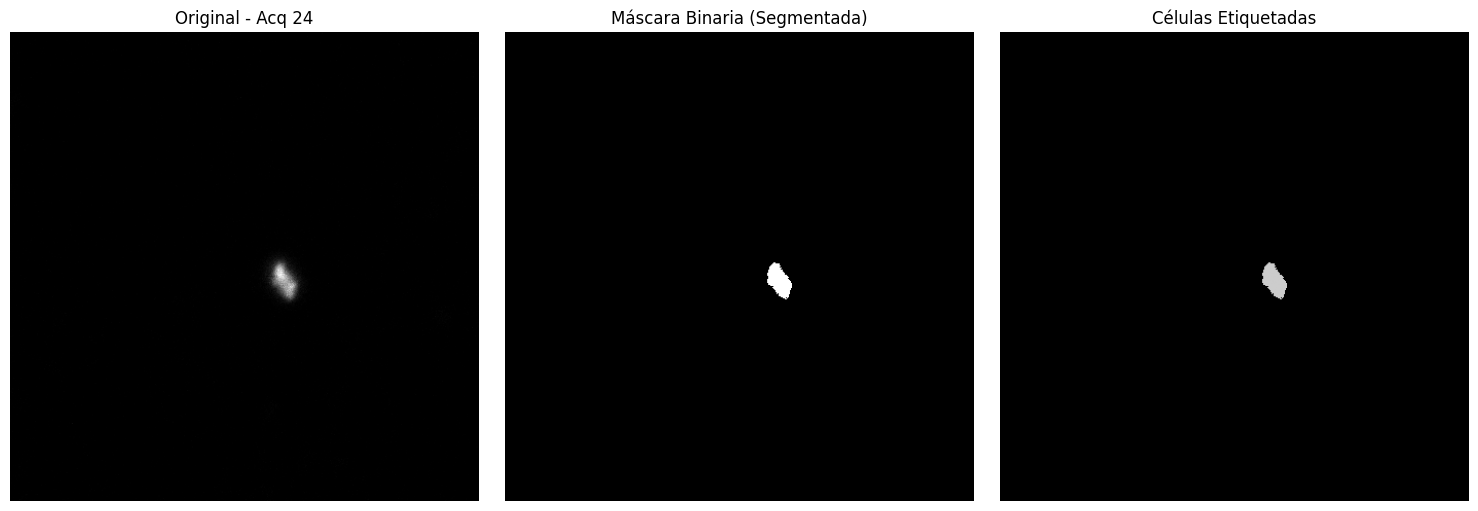

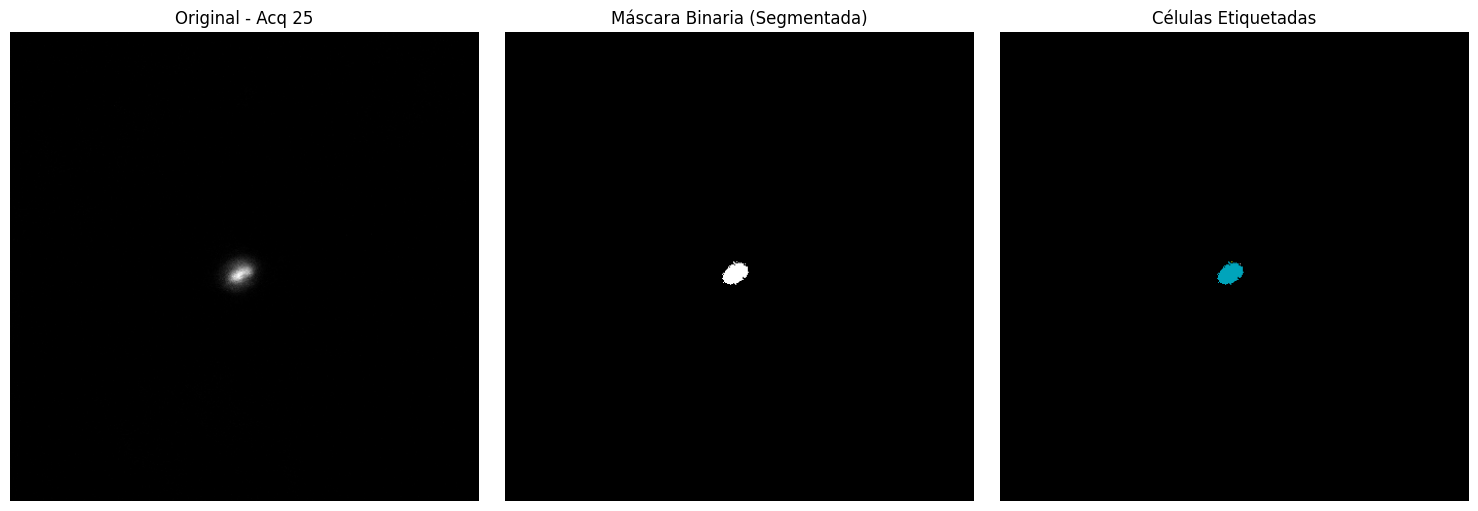

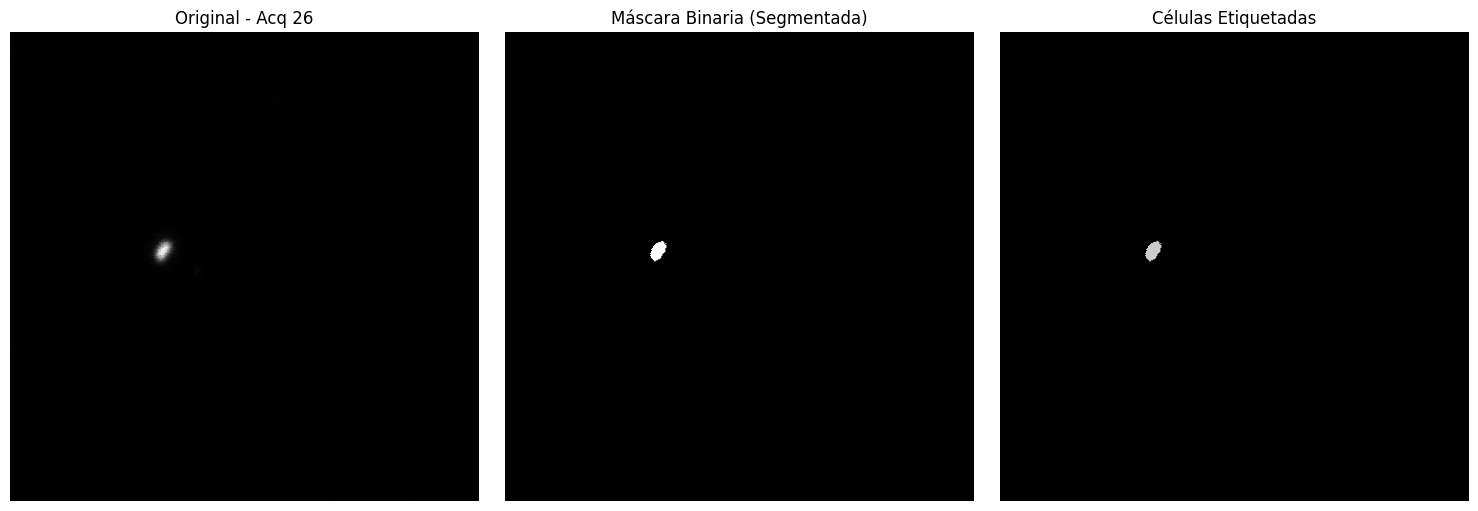

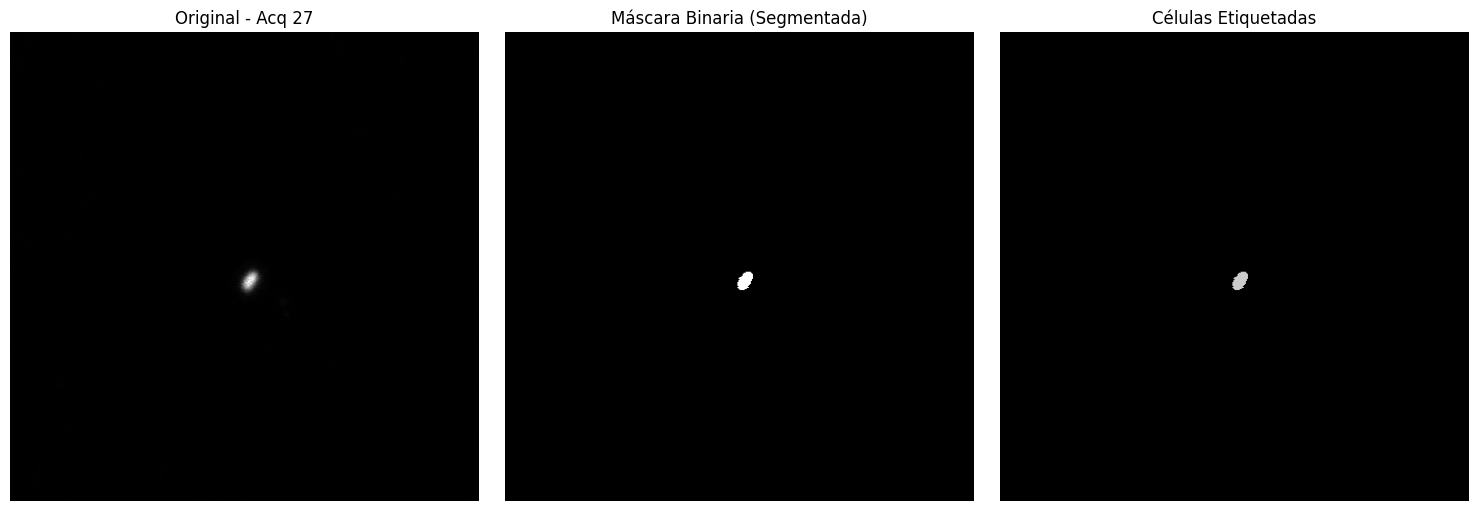

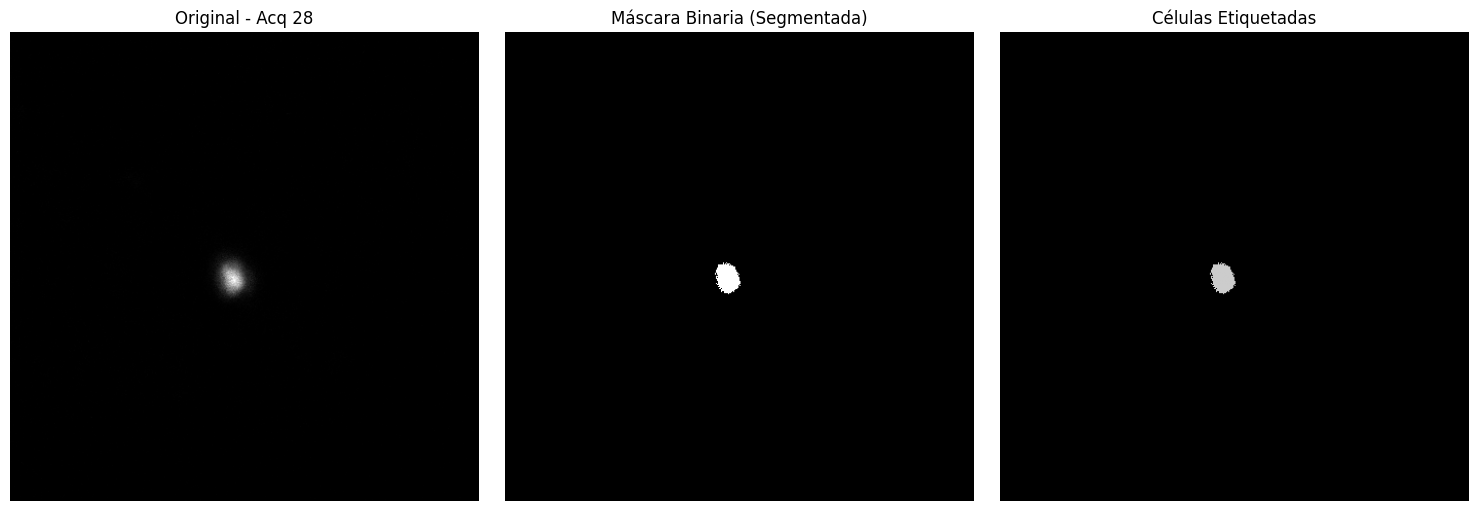


--- Resultados del Análisis de Intensidad (Todas las Células) ---
    label   area  mean_intensity  max_intensity  acquisition_id
0       1  677.0       93.354505          163.0               0
1       2    1.0       51.000000           51.0               0
2       1  311.0       48.019293          111.0               1
3       1  300.0      166.016667          255.0               2
4       1  244.0       55.028689          118.0               3
5       1  344.0      105.415698          192.0               4
6       1  372.0       88.427419          166.0               5
7       1  308.0      155.522727          255.0               6
8       2  139.0      125.129496          203.0               6
9       1   95.0      103.673684          164.0               7
10      2  236.0      141.491525          255.0               7
11      1    1.0       21.000000           21.0               8
12      2  431.0       38.554524           70.0               8
13      3    1.0       23.000000     

In [26]:
from readlif.reader import LifFile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Para mostrar los resultados en una tabla

# Importaciones clave de Scikit-image
from skimage.measure import label, regionprops_table
from skimage.filters import threshold_otsu # Un método automático de umbral

# --- Tu código para cargar ---
# Asegúrate de que 'file_path' tenga la ruta a tu archivo .lif
lif_path = file_path
lif = LifFile(lif_path)
images = list(lif.get_iter_image())
print(f"Número de adquisiciones: {len(images)}")

# --- Análisis de Intensidad ---

# 1. Corrección del bucle
print("Procesando imágenes y analizando células...")
all_results = [] # Lista para guardar los resultados de TODAS las imágenes

for i in range(len(images)): # Itera de 0 a 28
    image = images[i] # <-- CORRECCIÓN para usar la imagen actual del bucle

    # Carga el primer frame (canal 0) de la adquisición actual
    arr = image.get_frame(z=0, t=0, c=0)

    # Convert the readlif Image object to a NumPy array
    arr_np = np.array(arr)

    # 2. Segmentación (Thresholding)
    # El método de Otsu encuentra automáticamente un buen umbral
    # para separar el fondo de los objetos (células)
    try:
        # Use the NumPy array for thresholding
        thresh = threshold_otsu(arr_np)
        binary_mask = arr_np > thresh
    except ValueError:
        # Esto puede pasar si la imagen está completamente negra
        print(f"Omitiendo adquisición {i}: imagen vacía o sin varianza.")
        continue

    # 3. Etiquetado (Labeling)
    # Encuentra todos los objetos (células) separados y les asigna un ID
    labeled_image = label(binary_mask)

    # 4. Medición (Measurement)
    # Extrae las propiedades de cada región (célula) etiquetada
    # IMPORTANTE: Le pasamos 'intensity_image=arr' para que mida
    # las intensidades de la imagen ORIGINAL, no de la máscara.
    props = regionprops_table(
        labeled_image,
        intensity_image=arr_np, # Use the NumPy array for intensity measurement
        properties=('label', 'area', 'mean_intensity', 'max_intensity') # Removed 'total_intensity'
    )

    # Convertimos el diccionario de props a un DataFrame de pandas
    props_df = pd.DataFrame(props)

    # Añadimos una columna para saber de qué adquisición (imagen) viene
    props_df['acquisition_id'] = i

    all_results.append(props_df)

    # --- Opcional: Visualizar las primeras 2 segmentaciones ---
    #if i < 2:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(arr_np, cmap='gray') # Use the NumPy array for display
    axes[0].set_title(f"Original - Acq {i}")
    axes[0].axis('off')

    axes[1].imshow(binary_mask, cmap='gray')
    axes[1].set_title("Máscara Binaria (Segmentada)")
    axes[1].axis('off')

    # 'nipy_spectral' da buenos colores aleatorios para las etiquetas
    axes[2].imshow(labeled_image, cmap='nipy_spectral')
    axes[2].set_title("Células Etiquetadas")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


# --- Ver Resultados Finales ---
if all_results:
    # Combina todos los DataFrames individuales en una sola tabla
    final_results = pd.concat(all_results, ignore_index=True)

    print("\n--- Resultados del Análisis de Intensidad (Todas las Células) ---")
    print(final_results)

    # Ejemplo de cómo ver un resumen estadístico de la intensidad media
    print("\n--- Resumen de 'mean_intensity' ---")
    print(final_results['mean_intensity'].describe())
else:
    print("No se detectaron células en ninguna adquisición.")

In [27]:
# Definimos el nombre del archivo de salida
output_filename = 'resultados_intensidad.xlsx'

# Usamos la función .to_excel() de pandas
# 'index=False' es importante para no guardar el índice de pandas (0, 1, 2...)
# como una columna extra en el Excel.
try:
    final_results.to_excel(output_filename, index=False)
    print(f"✅ ¡Éxito! Los datos se han guardado en el archivo: '{output_filename}'")
except NameError:
    print("⚠️ Error: No se encontró la variable 'final_results'.")
    print("Asegúrate de haber ejecutado la celda de análisis anterior primero.")
except Exception as e:
    print(f"Ocurrió un error inesperado al guardar el archivo: {e}")

✅ ¡Éxito! Los datos se han guardado en el archivo: 'resultados_intensidad.xlsx'


In [28]:
# Definimos la ruta completa en tu Google Drive para que se guarde de forma permanente
output_filename = '/content/drive/MyDrive/2025 Josue Villegas/ICFO/resultados_intensidad.xlsx'

# Usamos la función .to_excel() de pandas
# 'index=False' es importante para no guardar el índice de pandas (0, 1, 2...)
# como una columna extra en el Excel.
try:
    final_results.to_excel(output_filename, index=False)
    print(f"✅ ¡Éxito! Los datos se han guardado de forma permanente en: '{output_filename}'")
except NameError:
    print("⚠️ Error: No se encontró la variable 'final_results'.")
    print("Asegúrate de haber ejecutado la celda de análisis anterior primero.")
except Exception as e:
    print(f"Ocurrió un error inesperado al guardar el archivo: {e}")

✅ ¡Éxito! Los datos se han guardado de forma permanente en: '/content/drive/MyDrive/2025 Josue Villegas/ICFO/resultados_intensidad.xlsx'
